In [1]:
import pandas as pd
import numpy as np
from scipy import stats
from scipy.stats import chi2_contingency

In [2]:
page_a = pd.read_csv("data/eniac_a.csv")
page_b = pd.read_csv("data/eniac_b.csv")
page_c = pd.read_csv("data/eniac_c.csv")
page_d = pd.read_csv("data/eniac_d.csv")

### Data Exploration
Snapshot column has information on visits.
From page a and b considering clicks for "Show Now" and page c and d considering clicks for "See Deals"
Following the beow steps to form contingency table "observed_results"

In [3]:
print(page_a['Snapshot information'].iloc[1])

created 2021-09-14   •   14 days 0 hours 34 mins   •   25326 visits, 23174 clicks


In [4]:
page_a[page_a['Name'] == 'SHOP NOW']

,Element ID,Tag name,Name,No. clicks,Visible?,Snapshot information
21,106,a,SHOP NOW,512,True,NaN


In [5]:
page_b[page_b['Name'] == 'SHOP NOW']

,Element ID,Tag name,Name,No. clicks,Visible?,Snapshot information
21,126,a,SHOP NOW,281,True,NaN


In [6]:
page_c[page_c['Name'] == 'SEE DEALS']

,Element ID,Tag name,Name,No. clicks,Visible?,Snapshot information
21,127,a,SEE DEALS,527,True,NaN


In [7]:
page_d[page_d['Name'] == 'SEE DEALS']

,Element ID,Tag name,Name,No. clicks,Visible?,Snapshot information
21,128,a,SEE DEALS,193,True,NaN


# Hypothesis testing: Chi-Square Test within the Eniac case study

In this notebook we perform a chi-square test with the data from the Eniac case study, applying a post-hoc correction to perform pairwise tests and find the true winner.

## 1.&nbsp;State the Null Hypothesis and the Alternative Hypothesis.

Null Hypothesis - All versions have same CTR
Alternate Hypothesis - All versions do not have same CTR

## 2.&nbsp; Select an appropriate significance level alpha ($\alpha$).

In [8]:
alpha = 0.05

## 3.&nbsp; Collect data that is random and independent

The important pieces of information (clicks on each element of interest & visits on each page) are scattered around. Let's collect them. Where are the .csv files? 🥸

In [9]:
# The hard coded numbers came from filtering each page_X DataFrame. Reference under Data Exploration.
Click = [512, 281, 527, 193]
No_click = [25326 - 512, 24747 - 281, 24876 - 527, 25233 - 193]

observed_results = pd.DataFrame(
    [Click, No_click], columns=["A", "B", "C", "D"], index=["Click", "No-click"]
)
observed_results

,A,B,C,D
Click,512,281,527,193
No-click,24814,24466,24349,25040


## 4.&nbsp; Calculate the test result

In [10]:
chisq, p_value, df, expected = chi2_contingency(observed_results)
print(f"chi-square statistic: {chisq:.4f}")
print(f"p_value: {p_value}")
print(f"degrees of freedom: {df}")

chi-square statistic: 224.0188
p_value: 2.7161216607868712e-48
degrees of freedom: 3


In [11]:
print("Reject H0" if p_value < alpha else "Fail to reject H0")

Reject H0


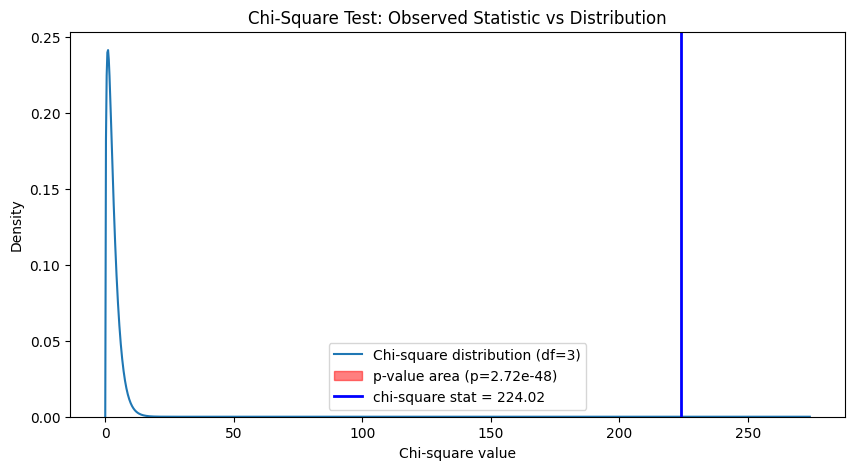

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2

x = np.linspace(0, chisq + 50, 1000)
y = chi2.pdf(x, df=df)

plt.figure(figsize=(10, 5))
plt.plot(x, y, label=f"Chi-square distribution (df={df})")

# Shade the p-value area (region more extreme than your chi-square statistic)
plt.fill_between(x, y, where=(x >= chisq), color='red', alpha=0.5, label=f"p-value area (p={p_value:.2e})")

# Vertical line for your chi-square statistic
plt.axvline(chisq, color='blue', linewidth=2, label=f"chi-square stat = {chisq:.2f}")

plt.title("Chi-Square Test: Observed Statistic vs Distribution")
plt.xlabel("Chi-square value")
plt.ylabel("Density")
plt.ylim(bottom=0)
plt.legend()
plt.show()

## 5.&nbsp; Interpret the test result

CTR is not the same across all four SHOP NOW/SEE DEALS button versions.

## How do we decide who's the winner?

A statistically significant result doesn't tell us which versions are best, it just tells us that at least one version is better or worse than another. To get more detailed comparisons we need to do post-hoc testing which performs a new test with each unique pair of versions.

Those unique pairs are:<br>
A B<br>
A C<br>
A D<br>
B C<br>
B D<br>
C D<br>

### Post-Hoc Testing

In [13]:
num_tests = 3 + 2 + 1 + 0
adjusted_alpha = alpha / num_tests

In [14]:
from scipy.stats import chi2_contingency
from itertools import combinations

versions = ['A', 'B', 'C', 'D']
results = []

for v1, v2 in combinations(versions, 2):
    pair_table = observed_results[[v1, v2]]
    chisq, pvalue, df, expected = chi2_contingency(pair_table)
    significant = pvalue < adjusted_alpha
    results.append({'comparison': f'{v1} vs {v2}', 'p_value': pvalue, 'significant': significant})

posthoc_df = pd.DataFrame(results)
posthoc_df

,comparison,p_value,significant
0,A vs B,2.673088e-15,True
1,A vs C,4.648421e-01,False
2,A vs D,3.080898e-33,True
3,B vs C,6.955480e-18,True
4,B vs D,2.357337e-05,True
5,C vs D,6.450501e-37,True


In [15]:
ctrs = (observed_results / observed_results.sum()).iloc[0,:]
ctrs.name = 'CTR'
ctrs

A    0.020216
B    0.011355
C    0.021185
D    0.007649
Name: CTR, dtype: float64

# Conclusion

Versions A and C are statistically tied for the highest CTR, both significantly outperforming Versions B and D. Version D performs significantly less than all other versions.